In [6]:
# Import basic libraries for data handling and visualization
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load MNIST dataset from Keras
from tensorflow.keras.datasets import mnist

# Build Neural Network model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout

# Convert labels to one-hot encoding
from tensorflow.keras.utils import to_categorical

# Confusion matrix for evaluation
from sklearn.metrics import confusion_matrix

In [7]:
# Load MNIST dataset (handwritten digits 0-9)
# x = images, y = labels
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
# Check dataset shapes
print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)

print("Testing images shape:", x_test.shape)
print("Testing labels shape:", y_test.shape)

Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing images shape: (10000, 28, 28)
Testing labels shape: (10000,)


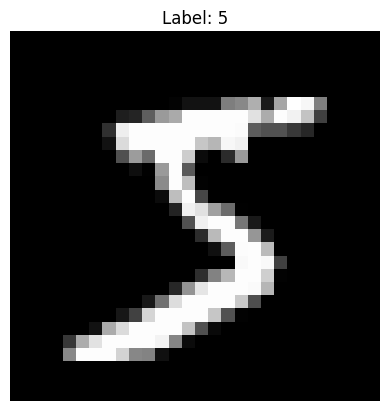

In [9]:
# Display one sample image from dataset
plt.imshow(x_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.axis('off')
plt.show()

In [10]:
# Normalize pixel values (0-255 → 0-1)
# This helps model learn faster
x_train = x_train / 255.0
x_test = x_test / 255.0

In [11]:
# Convert labels into categorical format (0 → [1,0,0,...])
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [12]:
# Create Sequential Neural Network model
model = Sequential()

# Flatten 28x28 image into 1D vector
model.add(Flatten(input_shape=(28, 28)))

# Hidden layer with ReLU activation
model.add(Dense(128, activation='relu'))

# Dropout to reduce overfitting
model.add(Dropout(0.2))

# Output layer (10 classes → digits 0-9)
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
# Show model architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Configure model training process
model.compile(
    optimizer='adam',  # optimizer
    loss='categorical_crossentropy',  # loss function for classification
    metrics=['accuracy']  # evaluation metric
)

In [15]:
# Train model on training data
history = model.fit(
    x_train,
    y_train,
    epochs=10,  # number of training rounds
    validation_split=0.2  # 20% for validation
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9061 - loss: 0.3251 - val_accuracy: 0.9526 - val_loss: 0.1697
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9533 - loss: 0.1572 - val_accuracy: 0.9644 - val_loss: 0.1196
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9646 - loss: 0.1179 - val_accuracy: 0.9696 - val_loss: 0.1029
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9711 - loss: 0.0963 - val_accuracy: 0.9728 - val_loss: 0.0954
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9756 - loss: 0.0807 - val_accuracy: 0.9733 - val_loss: 0.0867
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9783 - loss: 0.0699 - val_accuracy: 0.9753 - val_loss: 0.0875
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9798 - loss: 0.0623 - val_accuracy: 0.9762 - val_loss: 0.0823
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9821 - loss: 0.0554 -

In [16]:
# Evaluate model on unseen test data
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9797 - loss: 0.0721
Test Loss: 0.07211259007453918
Test Accuracy: 0.9797000288963318


In [19]:
# Make predictions on test data
predictions = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


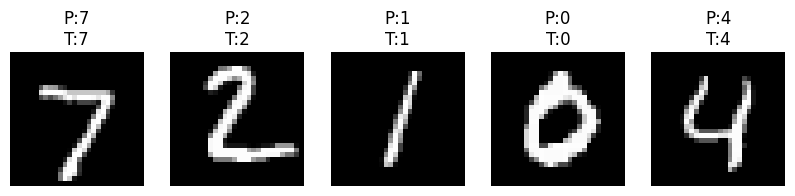

In [20]:
# Show sample predictions vs actual labels
plt.figure(figsize=(10,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(x_test[i], cmap='gray')

    pred = np.argmax(predictions[i])
    true = np.argmax(y_test[i])

    plt.title(f"P:{pred}\nT:{true}")
    plt.axis('off')

plt.show()

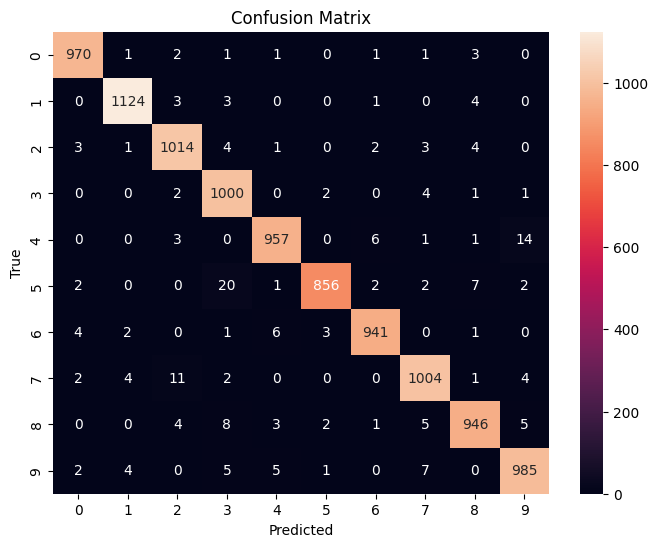

In [21]:
# Convert predictions to class labels
y_pred = np.argmax(predictions, axis=1)
y_true = np.argmax(y_test, axis=1)

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.show()

In [22]:
# Build second model with different activation function (Tanh)
model2 = Sequential()

model2.add(Flatten(input_shape=(28, 28)))

model2.add(Dense(128, activation='tanh'))  # changed activation

model2.add(Dropout(0.2))

model2.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [23]:
# Compile second model
model2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [24]:
# Train second model
history2 = model2.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8987 - loss: 0.3436 - val_accuracy: 0.9435 - val_loss: 0.2042
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9402 - loss: 0.2018 - val_accuracy: 0.9548 - val_loss: 0.1554
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9533 - loss: 0.1571 - val_accuracy: 0.9613 - val_loss: 0.1329
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9605 - loss: 0.1277 - val_accuracy: 0.9676 - val_loss: 0.1136
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9658 - loss: 0.1119 - val_accuracy: 0.9693 - val_loss: 0.1062
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9696 - loss: 0.0975 - val_accuracy: 0.9691 - val_loss: 0.1027
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9713 - loss: 0.0887 - val_accuracy: 0.9709 - val_loss: 0.0951
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9762 - loss: 0.0755 - 

In [25]:
# Evaluate second model
test_loss2, test_accuracy2 = model2.evaluate(x_test, y_test)

print("Tanh Model Results")
print("Test Loss:", test_loss2)
print("Test Accuracy:", test_accuracy2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9734 - loss: 0.0829
Tanh Model Results
Test Loss: 0.08290957659482956
Test Accuracy: 0.9733999967575073


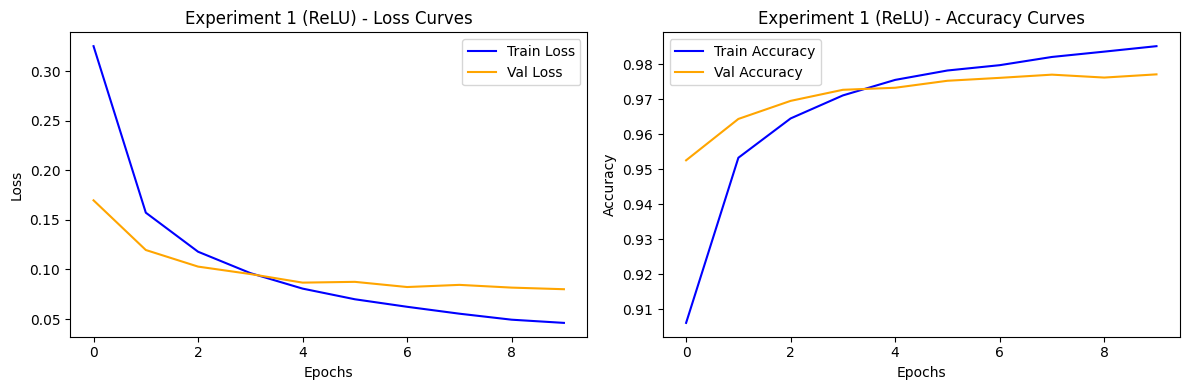

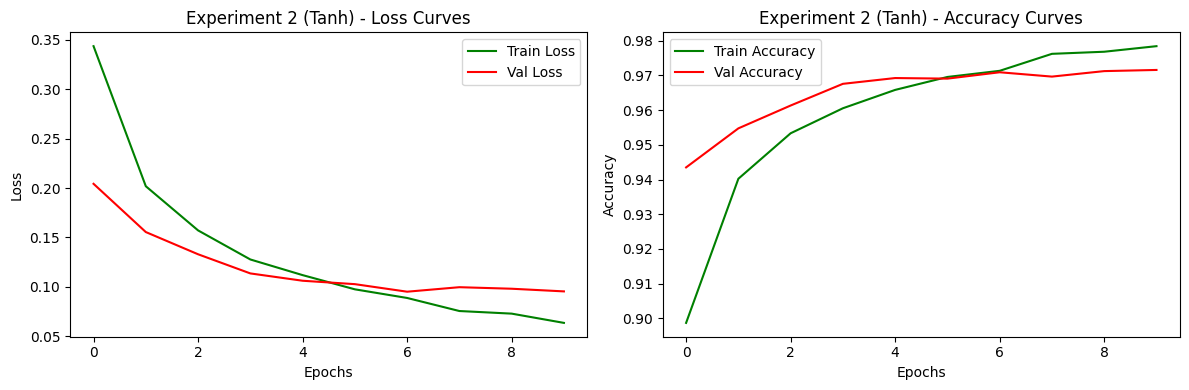

===== ReLU Model =====
Accuracy: 0.9797000288963318
Loss: 0.07211259007453918

===== Tanh Model =====
Accuracy: 0.9733999967575073
Loss: 0.08290957659482956


In [27]:
# --- رسم منحنيات التجربة الأولى (ReLU) ---
plt.figure(figsize=(12, 4))

# 1. منحنى الـ Loss للتجربة الأولى
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Val Loss', color='orange')
plt.title('Experiment 1 (ReLU) - Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# 2. منحنى الـ Accuracy للتجربة الأولى
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
plt.title('Experiment 1 (ReLU) - Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


# --- رسم منحنيات التجربة الثانية (Tanh) ---
plt.figure(figsize=(12, 4))

# 1. منحنى الـ Loss للتجربة الثانية
plt.subplot(1, 2, 1)
plt.plot(history2.history['loss'], label='Train Loss', color='green')
plt.plot(history2.history['val_loss'], label='Val Loss', color='red')
plt.title('Experiment 2 (Tanh) - Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# 2. منحنى الـ Accuracy للتجربة الثانية
plt.subplot(1, 2, 2)
plt.plot(history2.history['accuracy'], label='Train Accuracy', color='green')
plt.plot(history2.history['val_accuracy'], label='Val Accuracy', color='red')
plt.title('Experiment 2 (Tanh) - Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# طباعة المقارنة النهائية النصية اللي كانت عندك
print("===== ReLU Model =====")
print("Accuracy:", test_accuracy)
print("Loss:", test_loss)

print("\n===== Tanh Model =====")
print("Accuracy:", test_accuracy2)
print("Loss:", test_loss2)